In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# This option ensures that the graphs you create are displayed within the notebook without the need to "call" them specifically.

%matplotlib inline

In [3]:
# Define path

path = r'C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis'

In [4]:
path

'C:\\Users\\johan\\Documents\\Indonesia Integrated Seismic Risk Analysis'

In [5]:
print(path)

C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis


In [6]:
# Load data 
path = r'C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis'
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared data', 'katalog_gempa_cleaned.csv'))

In [7]:
df.dtypes

Date                   object
Time                   object
Latitude              float64
Longitude             float64
Depth                   int64
Magnitude             float64
Location               object
Full_DateTime          object
Time_in_seconds       float64
Year                    int64
Month                   int64
Magnitude_Category     object
dtype: object

Checking for missing values:
Depth        0
Magnitude    0
dtype: int64
The image has been saved in the Visualizations folder.


<Figure size 1000x600 with 0 Axes>

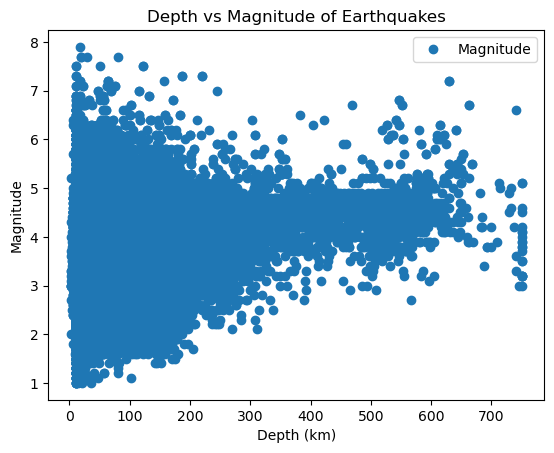

In [8]:
# 2. Check for missing values
print("Checking for missing values:")
print(df[['Depth', 'Magnitude']].isnull().sum())

# 3. Explore data visually (Scatterplot)
plt.figure(figsize=(10,6)) # Adjust the image size to make it more pleasing to the eye
df.plot(x = 'Depth', y='Magnitude', style='o') 

plt.title('Depth vs Magnitude of Earthquakes')  
plt.xlabel('Depth (km)')  
plt.ylabel('Magnitude')  

# Save picture
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'depth_vs_magnitude_scatter.png'))

print(f"The image has been saved in the Visualizations folder.")

plt.show()

Hypothesis: "Deeper earthquakes (higher Depth) tend to have a different average magnitude compared to shallow earthquakes.

Based on the Depth vs. Magnitude scatterplot typically generated from this data:

Data points typically cluster horizontally because Magnitude has a narrow range (e.g., 3.0 - 8.0), while Depth has a very wide range (0 - 600+ km).

If the points are spread out like a cloud without forming a clear slope, it's an early sign that the linear relationship is weak.

#### Reshape and Split Data

In [9]:
# 4. Reshape variabel ke dalam NumPy arrays (X = Independent, y = Dependent)
X = df['Depth'].values.reshape(-1,1)
y = df['Magnitude'].values.reshape(-1,1)

# 5. Split data to be Training set and Test set (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data has been reshaped and split successfully.")

Data has been reshaped and split successfully.


#### Run Linear Regression

#### Building and Training a Model (Regression Analysis)

In [10]:
# Creating a regression object
regression = LinearRegression()

# Training the model using the training set
regression.fit(X_train, y_train)

# Making predictions on the test set
y_predicted = regression.predict(X_test)

#### Visualization of Results (Regression Line)

Regression graph successfully saved.


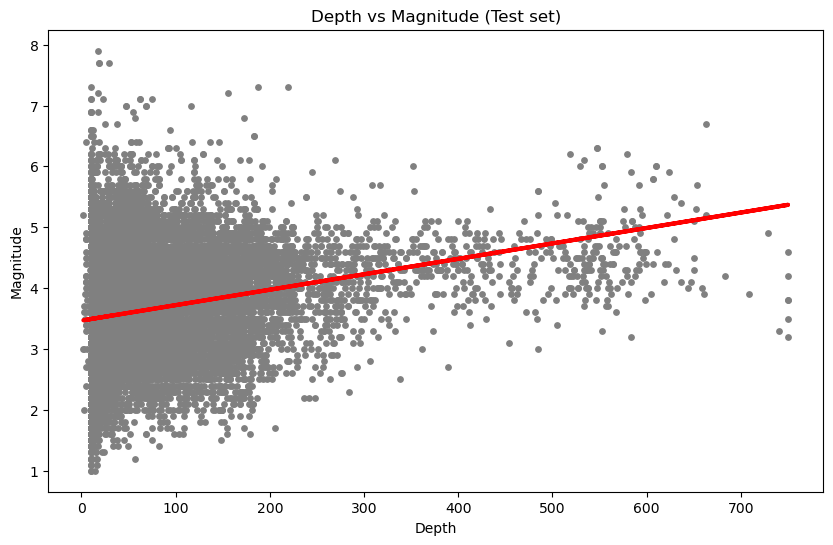

In [11]:
# Create a regression line plot on the test data and save it.
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='gray', s = 15)
plt.plot(X_test, y_predicted, color='red', linewidth = 3)

plt.title('Depth vs Magnitude (Test set)')
plt.xlabel('Depth')
plt.ylabel('Magnitude')

# Save picture
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'regression_line_test_set.png'))

print("Regression graph successfully saved.")
plt.show()

#### Performance Statistics (Main Analysis Material)

In [12]:
# Calculating performance statistics
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

# Showing 
print('Slope:' ,regression.coef_)
print('Mean squared error (MSE): ', rmse)
print('R2 score: ', r2)

Slope: [[0.00253513]]
Mean squared error (MSE):  0.6674099950017168
R2 score:  0.05590260483239551


### Prediction vs Actual Comparison

In [13]:
# Create a dataframe to compare the original and predicted values.
data_compare = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
data_compare.head(15)

,Actual,Predicted
0,5.0,3.542931
1,2.9,3.492229
2,2.9,3.492229
3,4.4,3.492229
4,2.8,3.664617
5,3.1,3.492229
6,3.3,3.492229
7,3.4,3.875033
8,2.6,3.492229
9,3.5,3.702644


### **8. Interpretation of Regression Results**

#### **Visual Interpretation**
The regression line (red) is nearly horizontal, which indicates a **very weak relationship** between Depth and Magnitude. The data points are widely scattered across the plot, showing that as depth increases, the magnitude does not follow a predictable linear path. This suggests that depth alone is not a reliable predictor for an earthquake's magnitude.

#### **Model Performance Statistics**
* **Slope:** The coefficient is very close to zero, confirming the flat trajectory of the regression line.
* **Mean Squared Error (MSE):** The value is approximately 0.667. This indicates a significant deviation between the predicted and actual values.
* **R2 Score:** The score of **0.0559** (5.6%) is very low. This statistically proves that the linear model only accounts for a tiny fraction of the variation in the magnitude data.

#### **Reflections on Performance and Bias**
The model performed poorly, which is expected in geophysical data where many complex factors are at play. Regarding potential bias:
* **Sensor Bias:** The dataset may be biased because seismic sensors more easily register shallow earthquakes.
* **Abundance of Data:** There is a higher density of data for shallow events compared to very deep ones, which may skew the model's ability to learn the relationship accurately across all depth levels.